# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import os, pathlib, subprocess, sys
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
TARGET = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
TARGET.parent.mkdir(parents=True, exist_ok=True)
if not TARGET.exists():
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
print(f'COURSE_ROOT={TARGET}')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 16</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Proyecto final</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="../assets/audio/notebooks/16_proyecto_final_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Qué evidencia técnica debe presentar un estudiante para defender que comprende un mini Transformer autoregresivo?

Este notebook cierra la ruta del curso. Ya construimos la cadena completa: secuencias, tokens, embeddings, posición, tensores, atención, Q/K/V, máscara causal, multi-head attention, bloque decoder, mini-GPT, entrenamiento y generación.

El proyecto final no se evalúa por producir una muestra vistosa. Se evalúa por la capacidad de conectar decisiones, ecuaciones, formas tensoriales, código, visualizaciones, métricas y límites en una defensa reproducible.


## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Definir una entrega final con evidencias mínimas de datos, arquitectura, entrenamiento, generación y límites.
2. Documentar formas tensoriales clave: $(B,T)$, $(B,T,C)$, $(B,H,T,T)$ y $(B,T,V)$.
3. Justificar decisiones de tokenización, `block_size`, dimensión $C$, número de cabezas, capas y estrategia de muestreo.
4. Interpretar curvas, tablas y mapas de atención sin sobreafirmar lo que muestran.
5. Preparar una defensa técnica que distinga valor formativo, evidencia experimental y límites del mini modelo.


## Marco conceptual

El proyecto final integra todos los notebooks anteriores. Una entrega sólida no consiste en copiar celdas que ejecutan, sino en sostener una trazabilidad completa: de dónde vienen los datos, cómo se codifican, qué arquitectura se usa, qué tensores aparecen, cómo se entrena, cómo se genera y qué errores se observan.

La cadena de cierre del curso es:

$$
\text{datos} \rightarrow \text{tokenización} \rightarrow \text{arquitectura} \rightarrow \text{entrenamiento} \rightarrow \text{generación} \rightarrow \text{visualización} \rightarrow \text{errores} \rightarrow \text{defensa}.
$$

Cada elemento de la cadena debe tener evidencia. Una afirmación sin tabla, forma tensorial, curva, ejemplo o interpretación crítica no es suficiente para defender el proyecto.


## Mapa visual del notebook

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="../assets/figures/16_proyecto_final.png" alt="Proyecto final" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La figura resume el cierre: el proyecto debe reunir construcción, entrenamiento, generación, visualización e interpretación. La imagen no reemplaza la defensa técnica; sirve como mapa de las evidencias que deben aparecer en la entrega.


## Formulación matemática

La entrega puede verse como un conjunto de evidencias técnicas:

$$
\mathcal{E}=\{D,\mathcal{V},X,Y,f_\theta,\mathcal{L},G,A,R\}.
$$

Esta expresión se lee así: el proyecto debe documentar datos $D$, vocabulario $\mathcal{V}$, batches $X/Y$, modelo $f_\theta$, pérdida $\mathcal{L}$, generación $G$, atención o visualización $A$ y análisis de riesgos o límites $R$.

La defensa debe conectar la arquitectura con la tarea autoregresiva:

$$
f_\theta(X) = Z, \qquad Z\in\mathbb{R}^{B\times T\times V}.
$$

Esta ecuación se lee así: el modelo recibe índices de forma $(B,T)$ y produce logits de forma $(B,T,V)$, un vector de puntajes por vocabulario para cada posición del batch.

La evidencia de entrenamiento debe reportar al menos la pérdida de validación:

$$
\mathcal{L}_{val}= -\frac{1}{BT}\sum_{b,t}\log p_\theta(y_{b,t}\mid x_{b,\leq t}).
$$

Esta ecuación se lee así: la validación estima si el modelo asigna probabilidad al siguiente token en ejemplos que no se usaron para actualizar parámetros.

La evidencia de generación debe reconocer que el siguiente token es una muestra:

$$
x_{t+1}\sim \tilde{p}_\theta(\cdot\mid x_{\leq t}).
$$

Esta ecuación se lee así: una muestra generada no es una prueba de comprensión; es el resultado de una distribución aprendida y una estrategia de muestreo.


## Traducción tensorial

El proyecto debe documentar las formas principales y explicar qué significa cada eje:

| Forma | Objeto | Lectura |
|---:|---|---|
| $(B,T)$ | índices de entrada y targets | batch por tiempo |
| $(B,T,C)$ | embeddings y estados internos | batch, tiempo y canales |
| $(B,H,T,T)$ | pesos de atención | batch, cabezas, query y key |
| $(B,T,V)$ | logits | puntajes por vocabulario |

La defensa debe poder responder dónde aparece cada forma, qué operación la produce y qué error conceptual ocurriría si se interpreta mal.


## Preparación del entorno


In [1]:
from pathlib import Path
import importlib
import sys
import warnings

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import torch

warnings.filterwarnings("ignore", message="Pandas requires version .*", category=UserWarning)
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.proyecto_final_experimentos as proyecto_final_experimentos
import fundamentos_transformers.visualizacion as visualizacion

proyecto_final_experimentos = importlib.reload(proyecto_final_experimentos)
visualizacion = importlib.reload(visualizacion)

configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Evidencias mínimas de entrega

La siguiente tabla funciona como contrato de entrega. Cada fila debe aparecer en el proyecto con evidencia observable: tabla, curva, forma tensorial, visualización, salida generada o análisis escrito.


componente,evidencia minima,pregunta que responde,artefacto esperado
Datos y tokenizacion,"corpus, vocabulario, codificacion y ejemplos x/y decodificados",¿Que datos alimentan realmente al modelo?,tabla de vocabulario y batch
Arquitectura,"block_size, C, heads, layers, parametros y formas internas",¿Que modelo se construyo?,tabla de configuracion y formas
Atencion y mascara causal,mapa de atencion y verificacion de no mirar al futuro,¿Como se restringe el contexto autoregresivo?,heatmap e interpretacion
Entrenamiento,"curvas train/valid, loss y perplexity aproximada",¿El modelo se ajusta al corpus y como se valida?,curvas y tabla de metricas
Generacion,"comparacion de temperature, top-k y top-p con prompt fijo",¿Como cambia la salida al cambiar el muestreo?,tabla de generaciones
Limites,"errores observables, causa probable y precaucion interpretativa",¿Que no demuestra el modelo?,tabla de diagnostico


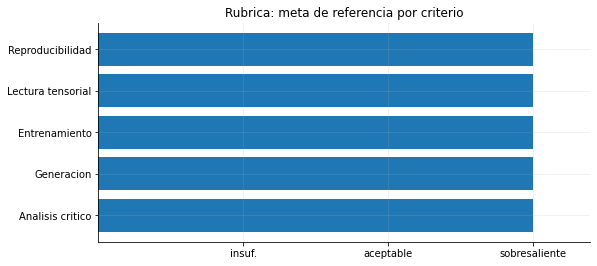

In [2]:
resultado_proyecto = proyecto_final_experimentos.preparar_material_proyecto_final()

mostrar_tablas_en_columnas(
    [("Evidencias mínimas", resultado_proyecto.evidencias)],
    min_width="760px",
)


## Rúbrica de evaluación

La rúbrica separa tres niveles. El nivel sobresaliente no exige un modelo grande; exige mayor claridad técnica, mejor trazabilidad y límites mejor defendidos.


criterio,insuficiente,aceptable,sobresaliente
Reproducibilidad,"faltan datos, semillas o configuracion",ejecuta con configuracion documentada,"incluye rutas, semillas, versiones y decisiones justificadas"
Lectura tensorial,menciona formas sin interpretarlas,explica formas principales,"conecta cada forma con operacion, eje y posible error conceptual"
Entrenamiento,solo reporta perdida final,incluye curvas train/valid,"interpreta ajuste, sobreajuste, perplexity y limites del corpus"
Generacion,muestra una salida sin configuracion,compara estrategias con prompt fijo,"relaciona distribucion, muestreo, errores y limites"
Analisis critico,sobreinterpreta resultados,reconoce limites principales,"separa sintoma, evidencia, causa probable y precaucion"


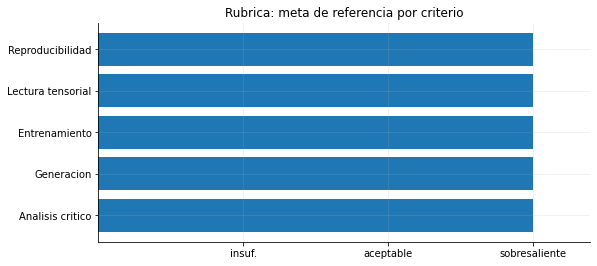

In [3]:
mostrar_tablas_en_columnas(
    [("Rúbrica", resultado_proyecto.rubrica)],
    min_width="760px",
)

display(resultado_proyecto.figura_rubrica)
plt.close(resultado_proyecto.figura_rubrica)


## Checklist de reproducibilidad

Antes de entregar, el estudiante debe poder ubicar cada una de estas evidencias en su notebook o informe técnico.


In [4]:
mostrar_tablas_en_columnas(
    [("Checklist de reproducibilidad", resultado_proyecto.checklist)],
    min_width="620px",
)


bloque,verificacion,evidencia
Ejecucion,el notebook corre de arriba abajo,sin errores ni celdas omitidas
Datos,corpus y tokenizacion documentados,tabla de vocabulario y ejemplos x/y
Modelo,configuracion completa,"block_size, C, heads, layers y parametros"
Metricas,train y valid separadas,curvas y tabla de loss/perplexity
Generacion,prompt fijo y configuraciones claras,tabla de salidas comparadas
Limites,diagnostico de errores,"sintoma, evidencia, causa probable y cautela"


## Preguntas obligatorias de defensa

Estas preguntas no son accesorias. Una entrega final sólida debe responderlas con evidencia concreta del proyecto, no con definiciones generales.


In [5]:
mostrar_tablas_en_columnas(
    [("Preguntas obligatorias de defensa", resultado_proyecto.preguntas_defensa)],
    min_width="720px",
)


categoria,pregunta,evidencia aceptable
Arquitectura,¿Que parte del modelo mezcla posiciones y que parte refina canales?,diagrama o tabla del bloque decoder con atencion y MLP
Q/K/V,"¿Donde aparecen Q, K y V en la implementacion y que forma tienen?",auditoria tensorial de proyeccion y cabezas
Causalidad,¿Por que la mascara causal evita fuga de futuro?,matriz triangular o mapa de atencion interpretado
Logits,"¿Que significan los logits $(B,T,V)$ antes de muestrear?",tabla de top tokens y softmax para una posicion
Limites,¿Que limitacion concreta observaste en una muestra generada?,ejemplo generado con diagnostico de error


## Errores frecuentes y correcciones

El proyecto final debe evitar errores de interpretación que suelen aparecer cuando el modelo genera algo visual o textualmente llamativo.


In [6]:
mostrar_tablas_en_columnas(
    [("Errores frecuentes y correcciones", resultado_proyecto.errores)],
    min_width="720px",
)


error frecuente,correccion esperada
Decir que el modelo comprende porque genera texto legible,separar fluidez local de comprension y reportar limites
Comparar estrategias de muestreo cambiando tambien el prompt,mantener prompt fijo para aislar el efecto del muestreo
Mostrar atencion como explicacion completa,presentarla como evidencia parcial y contextual
Reportar solo perdida de entrenamiento,incluir validacion y discutir sobreajuste
No documentar formas tensoriales,"auditar $(B,T)$, $(B,T,C)$, $(B,H,T,T)$ y $(B,T,V)$"


## Verificación de aprendizaje

Complete una autoevaluación de su proyecto. En cada fila, reemplace `por completar` por la celda, tabla, figura o sección donde aparece la evidencia.

La autoevaluación no debe decir simplemente “sí”. Debe apuntar a evidencia localizable.


In [7]:
mostrar_tablas_en_columnas(
    [("Autoevaluación final", resultado_proyecto.autoevaluacion)],
    min_width="620px",
)


pregunta,criterio de evidencia
¿Puedo reconstruir el experimento desde cero?,"si, con rutas, semillas y configuracion"
¿Cada afirmacion tiene evidencia?,"si, tabla, curva, mapa o ejemplo"
¿Distingo resultado de interpretacion?,"si, separo observacion y conclusion"
¿Declaro limites?,"si, no sobreinterpreto el mini modelo"


## Análisis crítico

**Qué demuestra el proyecto.** Una entrega bien construida demuestra que el estudiante puede implementar y rastrear un mini Transformer autoregresivo desde datos hasta generación.

**Qué evidencia lo sostiene.** La defensa debe apoyarse en batches, formas tensoriales, parámetros, curvas de pérdida, ejemplos generados, mapas de atención y diagnóstico de errores.

**Qué no se puede concluir.** El proyecto no demuestra que el modelo sea competitivo, que comprenda lenguaje en sentido amplio o que sus mapas de atención expliquen semánticamente cada salida. Su valor es formativo y experimental.


## Síntesis

La cadena de cierre del curso es:

$$
\text{datos} \rightarrow \text{tokenización} \rightarrow \text{arquitectura} \rightarrow \text{entrenamiento} \rightarrow \text{generación} \rightarrow \text{visualización} \rightarrow \text{errores} \rightarrow \text{defensa}.
$$

Esta cadena se lee así: el proyecto parte de datos concretos, construye representaciones y un modelo, entrena con una pérdida explícita, genera muestras bajo configuraciones controladas y cierra con límites verificables.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin-top: 10px;">
La idea central es que una defensa técnica vale más que una salida llamativa: el curso cierra cuando el estudiante puede explicar qué hizo, por qué funciona, qué evidencia tiene y qué no debe afirmar.
</div>


## Preguntas de discusión

1. ¿Qué evidencia muestra que el modelo aprendió patrones del corpus y no solo ejecutó una arquitectura?
2. ¿Dónde aparecen las formas $(B,T)$, $(B,T,C)$, $(B,H,T,T)$ y $(B,T,V)$ en su implementación?
3. ¿Qué comparación experimental permite analizar el efecto de temperatura, top-k o top-p?
4. ¿Qué límite concreto observó en la generación y qué evidencia lo respalda?
5. ¿Qué tendría que cambiar para pasar de este mini modelo formativo a un sistema moderno de mayor escala?


## Continuidad y cierre

Este notebook cierra la ruta de Fundamentos de Transformers. La continuidad natural está en cursos posteriores sobre modelos de lenguaje grandes, entrenamiento a escala, ajuste fino, evaluación avanzada y sistemas basados en modelos generativos.

La base técnica desarrollada aquí debe permanecer clara: antes de usar abstracciones de alto nivel, el estudiante debe poder explicar cómo una secuencia se convierte en tensores, cómo la atención mezcla información, cómo el decoder produce logits y cómo el entrenamiento ajusta parámetros por predicción del siguiente token.
